In [5]:
# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import mitsuba as mi
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# Query the Mitsuba variant that was automatically selected by Sionna RT.
# There should be no need to adjust it, but if you do, make sure to select
# a variant ending in `*_ad_mono_polarized`.
print(f"Mitsuba variant: {mi.variant()}")

Mitsuba variant: cuda_ad_mono_polarized


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!ls "/content/drive/MyDrive/sionna rt"

 glaishalle	        test10_gml   test18_gleishalle	'test_scene 3'
'glaishalle old file'   test11_gml   test_scene1


In [27]:
from sionna.rt import load_scene

scene = load_scene("/content/drive/MyDrive/sionna rt/test18_gleishalle/test18_gleishalle/siona_test_6_cleaned.xml")

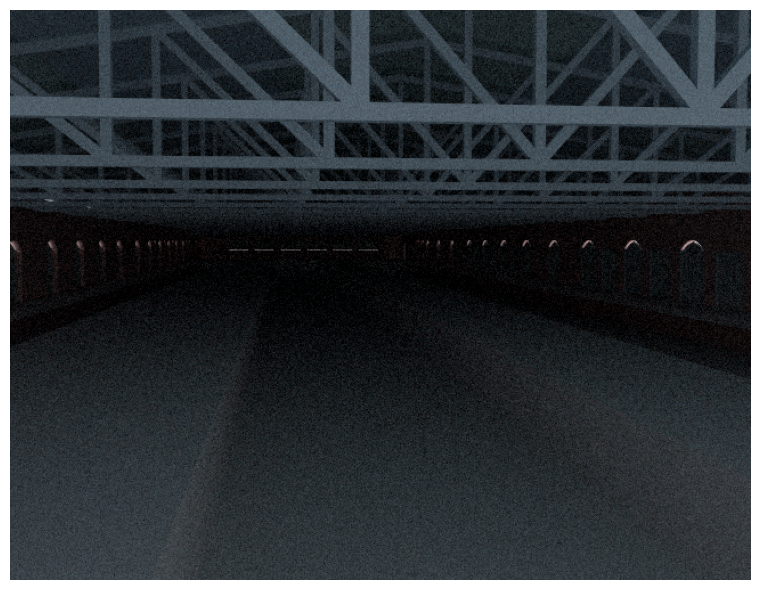

In [9]:
# Create new camera with different configuration
my_cam = Camera(position=[20,150,3], look_at=[5,20,-5])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=128);

In [28]:
# Wi-Fi carrier frequency (5 GHz)
scene.frequency = 5e9

# -----------------------------
# Access Point (Transmitter)
# -----------------------------
scene.tx_array = PlanarArray(
    num_rows=2,
    num_cols=2,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="VH"      # Dual polarization
)

# -----------------------------
# User Device (Receiver Array Setup)
# -----------------------------
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="dipole",
    polarization="V"
)

# -----------------------------
# Access Point (Transmitter)
# -----------------------------
tx = Transmitter(
    name="WiFi_AP",
    position=[8.87, 22.21, 3],
    display_radius=1
)
scene.add(tx)

# -----------------------------
# Receivers (5 Users Total)
# -----------------------------
rx1 = Receiver(name="WiFi_Client_1", position=[24.84, 138.8, 1.5], display_radius=1)
rx2 = Receiver(name="WiFi_Client_2", position=[30.0, 50.0, 2], display_radius=1)
rx3 = Receiver(name="WiFi_Client_3", position=[18.5, 231.5,3 ], display_radius=1)
rx4 = Receiver(name="WiFi_Client_4", position=[3.2, 97.0, 1], display_radius=1)
rx5 = Receiver(name="WiFi_Client_5", position=[13, 133.8, 1], display_radius=1)

# Add receivers to scene
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
scene.add(rx5)

# -----------------------------
# Point AP toward main client
# -----------------------------
tx.look_at(rx1)

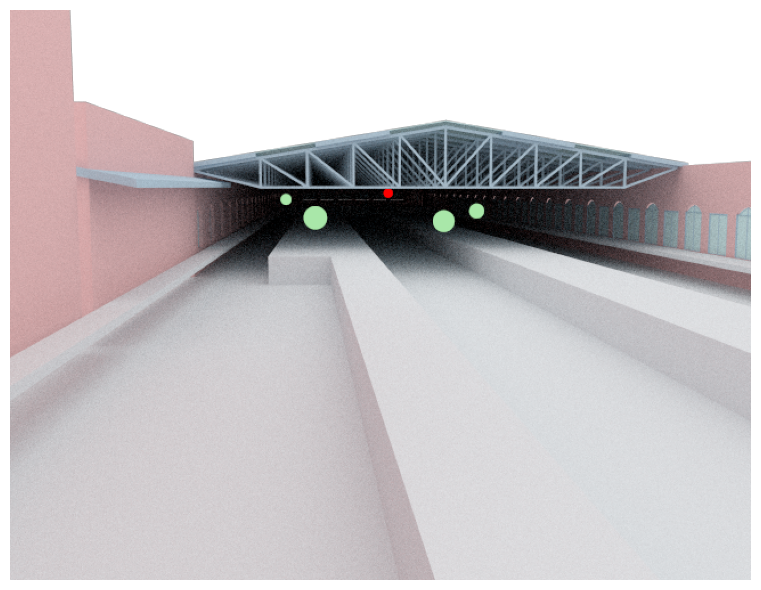

In [11]:
# Create new camera with different configuration
my_cam = Camera(position=[25,216,4], look_at=[10,15,-20])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=128);

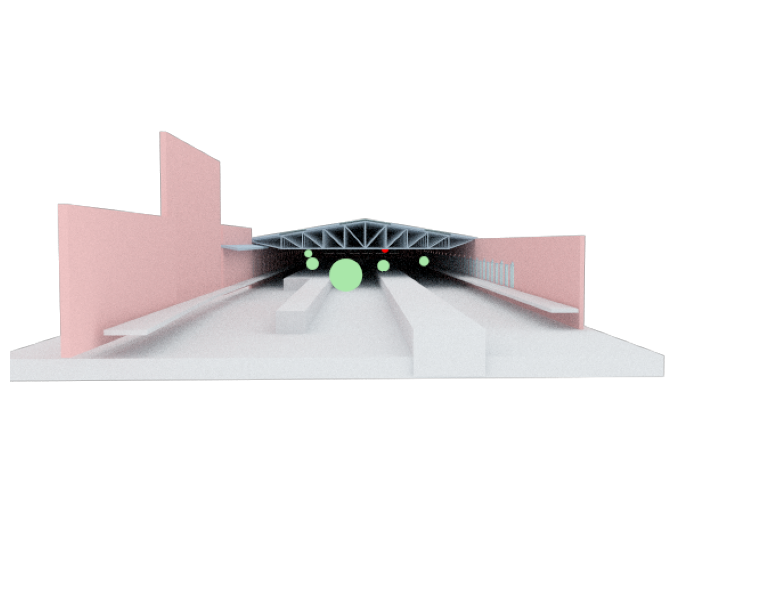

In [12]:
# Create new camera with different configuration
my_cam = Camera(position=[18,286,5], look_at=[10,15,-11])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=128);

In [29]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

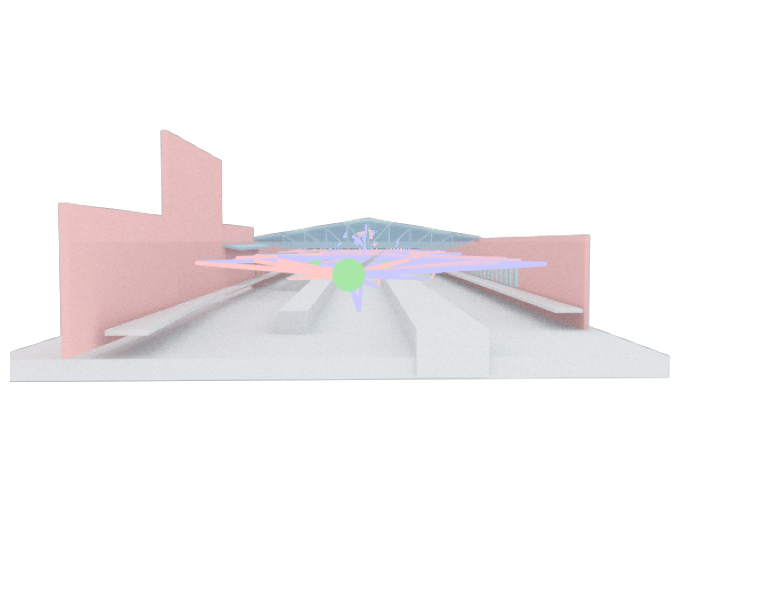

In [14]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=5);
else:
    scene.preview(paths=paths, clip_at=5);

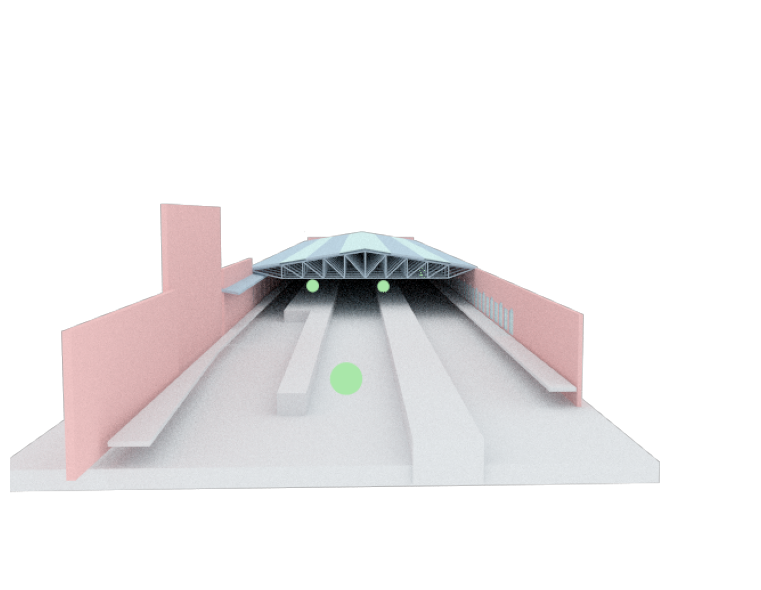

In [15]:
# Create new camera with different configuration
my_cam = Camera(position=[18,286,13], look_at=[10,15,-11])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=128);

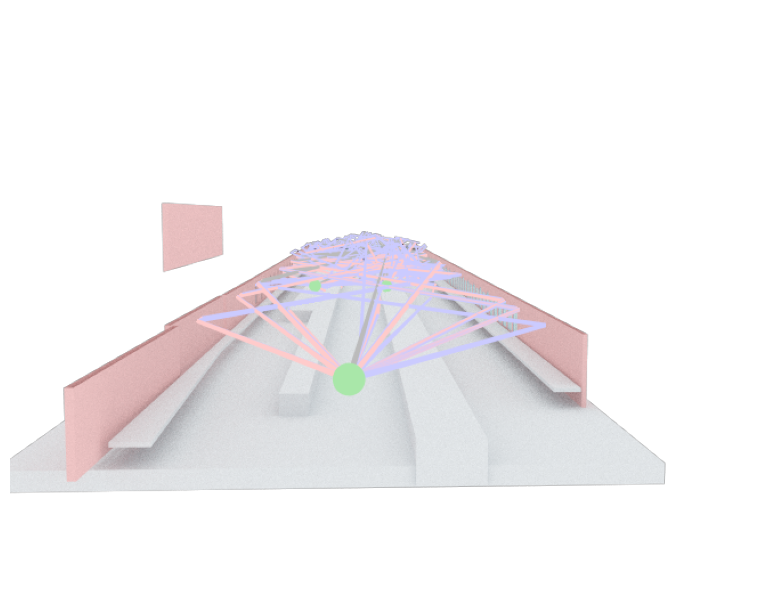

In [16]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=4);
else:
    scene.preview(paths=paths, clip_at=4);

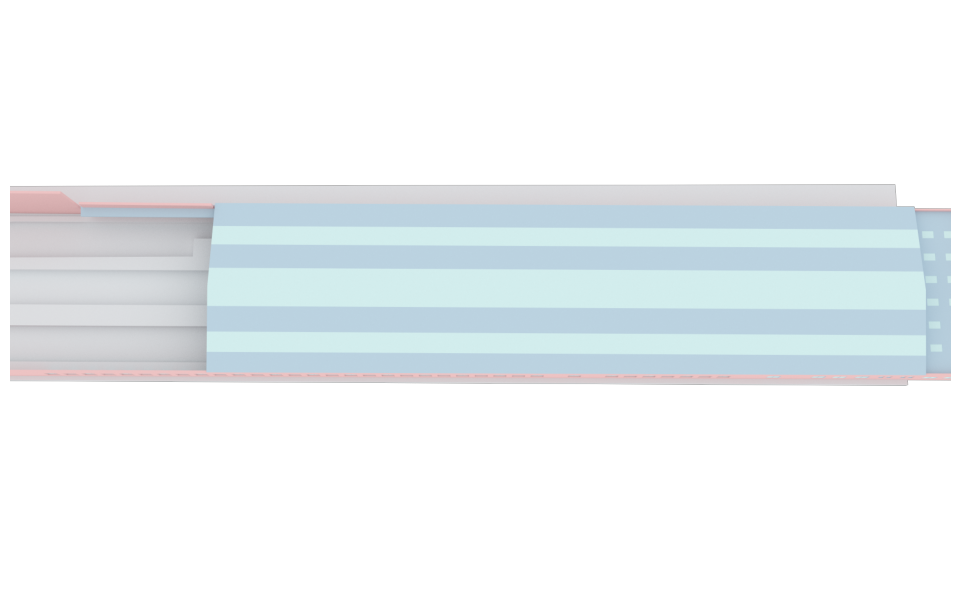

In [17]:
# Create new camera with different configuration
my_cam = Camera(position=[-25,106,220], look_at=[50,106,-180])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[1650, 1000], num_samples=1080);

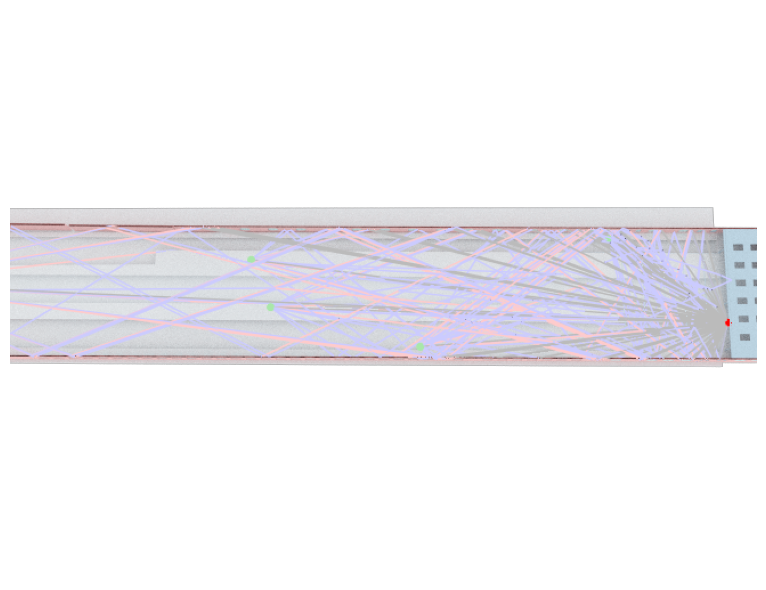

In [18]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=4);
else:
    scene.preview(paths=paths, clip_at=4);

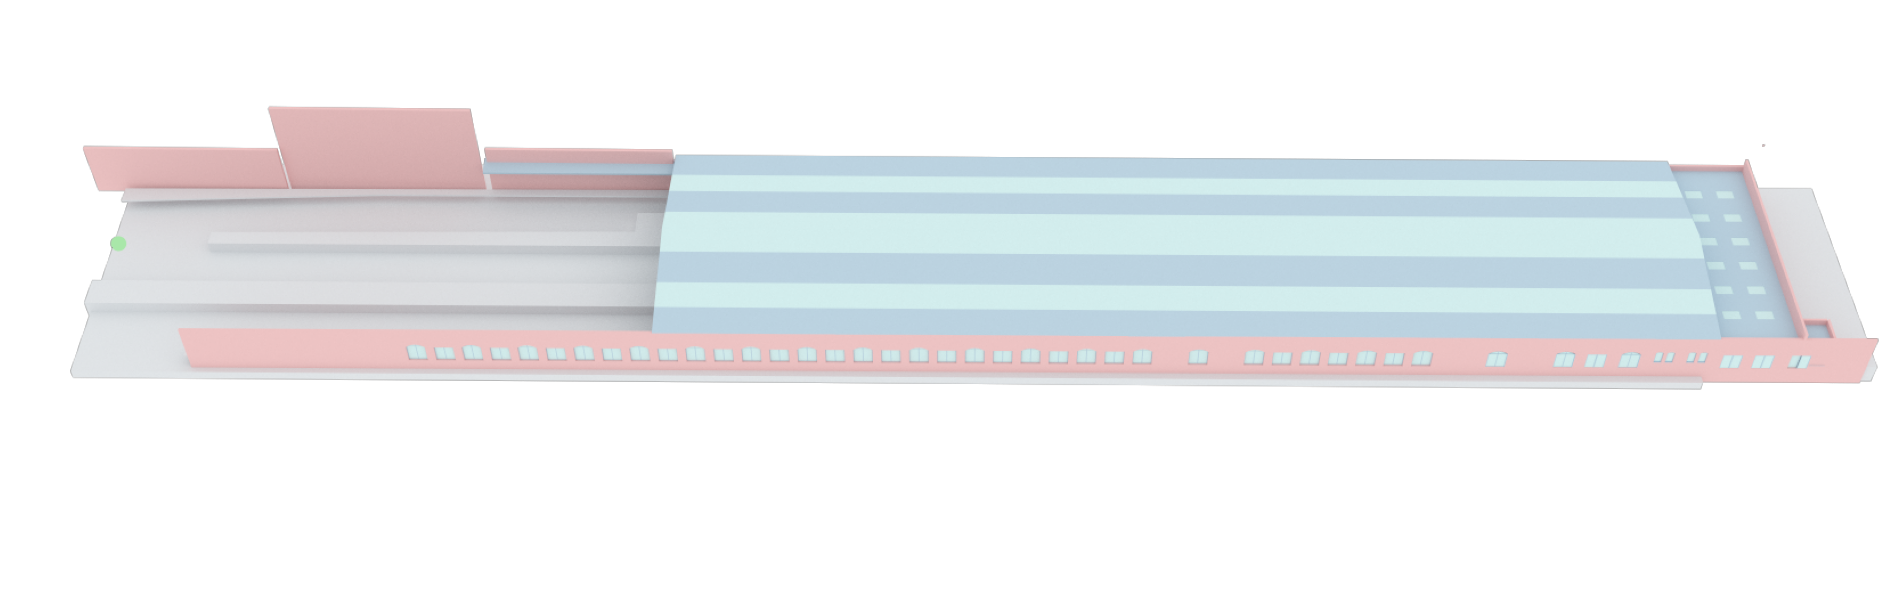

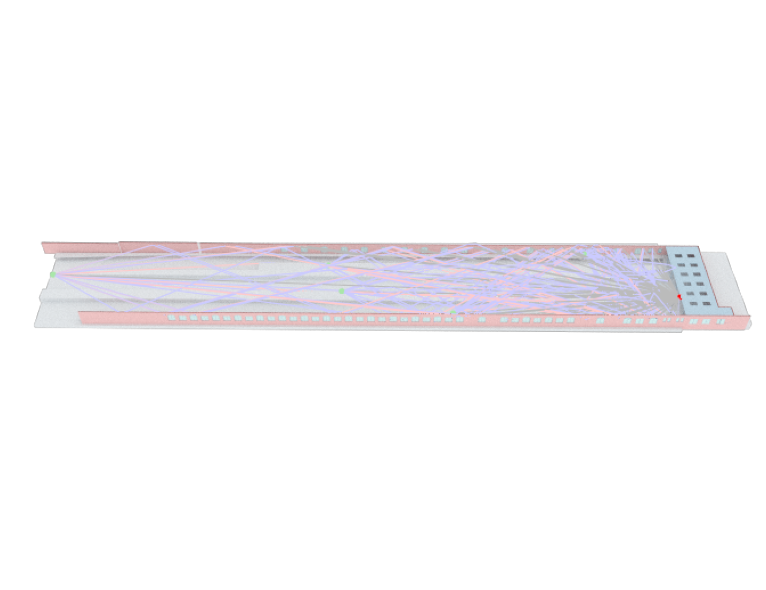

In [31]:
# Create new camera with different configuration
my_cam = Camera(position=[-195,119,220], look_at=[50,120,-40])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[1650,500], num_samples=1111);
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=4);
else:
    scene.preview(paths=paths, clip_at=4);

In [26]:
import numpy as np

# Extract channel impulse response
a, tau = paths.cir(
    normalize_delays=True,
    out_type="numpy"
)

# ---------------------------------
# Print channel dimensions
# ---------------------------------

# Shape of a:
# [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a:", a.shape)

# Shape of tau:
# [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau:", tau.shape)


# ---------------------------------
# Count multipath components
# for each Wi-Fi client
# ---------------------------------

print("\nMultipath count per Wi-Fi client:")
print("-" * 40)

# Get receiver names
wifi_clients = [rx.name for rx in scene.receivers.values()]

for i, client in enumerate(wifi_clients):

    # Extract all paths for one receiver
    # Shape:
    # [num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    rx_paths = a[i]

    # Check valid/non-zero paths
    valid_paths = np.any(
        np.abs(rx_paths) > 0,
        axis=(0,1,2,4)
    )

    # Count paths
    num_paths = int(np.sum(valid_paths))

    print(f"{client}: {num_paths} multipath components")

Shape of a: (5, 1, 1, 8, 151, 1)
Shape of tau: (5, 1, 1, 8, 151)

Multipath count per Wi-Fi client:
----------------------------------------
WiFi_Client_1: 81 multipath components
WiFi_Client_2: 151 multipath components
WiFi_Client_3: 124 multipath components
WiFi_Client_4: 120 multipath components
WiFi_Client_5: 71 multipath components
